# Informe integrado: PokeAPI + Smogon

Este informe presenta el grafo integrado como un motor de razonamiento
competitivo. Una base de datos permite preguntar "¿qué datos tiene este
Pokémon?"; el grafo permite preguntar "¿por qué encaja en una estrategia, qué
sinergias genera, qué alternativas existen y qué patrones competitivos emergen?".

Para eso se integra la estructura de PokeAPI (tipos, movimientos, evolución,
crianza, habilidades y estadísticas) con una capa competitiva de Smogon para
Gen 9 OU / Scarlet & Violet: uso, movimientos usados, objetos, habilidades,
compañeros y respuestas defensivas.


## 1. Introducción y motivación

El objetivo no es solo listar atributos, sino conectar entidades y relaciones
para apoyar decisiones de construcción de equipos. El grafo permite combinar:

- Estructura base de PokeAPI: especies, tipos, movimientos, evolución, crianza.
- Capa competitiva de Smogon: uso real, movimientos usados, objetos, habilidades,
  compañeros y respuestas defensivas.
- Algoritmos de grafo: centralidad, comunidades, similitud estructural y rutas
  explicativas.

La lectura estratégica del informe se organiza en seis preguntas de
investigación. Cada bloque mantiene consultas livianas o proyecciones ya usadas
por el reporte, de modo que el cuaderno siga ejecutando dentro del límite de
120 segundos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from IPython.display import display, Markdown

driver = GraphDatabase.driver('bolt://localhost:7687', auth=None)

def df(query):
    with driver.session() as session:
        return pd.DataFrame([r.data() for r in session.run(query)])

def run(query):
    with driver.session() as session:
        session.run(query)

def lista_texto(valores, max_items=3):
    valores = [str(v) for v in list(valores)[:max_items] if pd.notna(v)]
    if not valores:
        return "sin resultados visibles"
    if len(valores) == 1:
        return valores[0]
    return ", ".join(valores[:-1]) + " y " + valores[-1]

print('Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.')


Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.


## 2. Modelo del grafo integrado

El grafo representa nodos como `Pokemon`, `Species`, `Move`, `Type`,
`EggGroup`, `Format`, `Item` y `Ability`. Entre sus relaciones principales
están `CAN_LEARN`, `HAS_TYPE`, `COMPATIBLE`, `RUNS_MOVE`, `HOLDS_ITEM`,
`USES_ABILITY`, `TEAMMATE_OF` y `CHECKED_BY`.

La clave analítica está en cruzar capas. Un Pokémon no se interpreta solo por
sus atributos, sino por sus conexiones: qué movimientos usa, con quién aparece,
qué tipos cubre, qué lo amenaza y qué otros Pokémon ocupan posiciones parecidas.


In [2]:
labels = df('MATCH (n) UNWIND labels(n) AS label RETURN label, count(*) AS cantidad ORDER BY cantidad DESC')
display(labels)


,label,cantidad
0,Encounter,69714
1,Name,56842
2,Item,2176
3,PokemonForm,1579
4,Pokemon,1351
5,LocationArea,1249
6,Location,1096
7,Species,1025
8,Move,937
9,EvolutionCondition,550


Esta tabla ayuda a entender de qué está hecho el grafo antes de entrar en
los análisis competitivos. Cada fila corresponde a una clase de entidad, como
Pokémon, movimientos, tipos, habilidades, objetos o formatos. Un número alto
indica que esa capa tiene muchos nodos disponibles para ser conectados con el
resto del modelo.

La utilidad de esta mirada inicial es contextual. El reporte no razona desde una
tabla aislada, sino desde varias capas conectadas entre sí. Sin embargo, el
tamaño de una capa no significa automáticamente que sea la más importante para
competir; solo muestra cuánta información contiene esa parte del grafo.


In [3]:
rels = df('MATCH ()-[r]->() RETURN type(r) AS relacion, count(*) AS cantidad ORDER BY cantidad DESC')
display(rels)


,relacion,cantidad
0,CAN_LEARN,635905
1,COMPATIBLE,71232
2,HAS_ENCOUNTER,69714
3,AT_AREA,69714
4,HAS_NAME,56842
5,HAS_STAT,8100
6,HAS_ABILITY,2937
7,TEAMMATE_OF,2796
8,RUNS_MOVE,2344
9,HAS_TYPE,2115


Esta segunda tabla muestra las conexiones disponibles entre entidades. En
un grafo, las relaciones son tan importantes como los nodos, porque permiten
pasar de preguntas descriptivas a preguntas estratégicas. Por ejemplo,
`TEAMMATE_OF` conecta Pokémon que aparecen juntos en equipos, `RUNS_MOVE`
relaciona Pokémon con movimientos usados en el metajuego y `HAS_TYPE` permite
razonar sobre perfiles ofensivos y defensivos.

El conteo sirve para saber qué relaciones tienen más presencia en los datos,
pero debe leerse con cuidado. Una relación muy frecuente no siempre es la más
decisiva competitivamente: su valor depende de la pregunta que se esté
respondiendo y del contexto del formato analizado.


## 3. Preguntas de investigación y correspondencia analítica

Las preguntas que guían el reporte son:

1. ¿Qué Pokémon, movimientos, habilidades u objetos son más centrales dentro del grafo competitivo?
2. ¿Qué Pokémon pueden funcionar como sustitutos estratégicos de otros al armar un equipo?
3. ¿Qué tipos o combinaciones de tipos ofrecen mejores perfiles ofensivos y defensivos?
4. ¿Qué cores competitivos emergen en la red `TEAMMATE_OF` y qué los caracteriza?
5. ¿Qué cadenas de relaciones explican por qué un Pokémon encaja en una estrategia competitiva?
6. ¿Puede el grafo anticipar qué Pokémon podrían funcionar juntos en un equipo competitivo?

**Correspondencia entre preguntas, análisis y utilidad**

| Pregunta | Análisis usado | Parte del grafo | Utilidad estratégica | Limitación |
|---|---|---|---|---|
| 1. Centralidad competitiva | PageRank en `TEAMMATE_OF` y frecuencia de recursos usados | `Pokemon`, `Move`, `Ability`, `Item`, `Format` | Priorizar amenazas, recursos de preparación y piezas alrededor de las cuales se organiza el metajuego | La centralidad depende de los datos de uso de Smogon cargados y no reemplaza el juicio competitivo |
| 2. Sustitutos estratégicos | Similitud por repertorio de movimientos y tipos compartidos | `Pokemon`, `Move`, `Type` | Proponer alternativas cuando una pieza no está disponible o no calza con el equipo | No modela EVs, naturalezas, objetos ni rol exacto en batalla |
| 3. Perfiles ofensivos y defensivos | Perfiles individuales, perfiles dobles, ventajas x4 y resistencias x0.25 | `Type`, `EFFECTIVENESS`, `SUPER_EFFECTIVE`, `Pokemon` | Comparar cobertura ofensiva, debilidades, resistencias y neutralidades de tipos | No incorpora habilidades, objetos, movimientos concretos ni condiciones dinámicas de combate |
| 4. Cores competitivos | Louvain sobre la red `TEAMMATE_OF` | `Pokemon`, `TEAMMATE_OF`, `RUNS_MOVE`, `USED_IN` | Identificar grupos de Pokémon que aparecen juntos y caracterizar su plan de juego | Una comunidad sugiere core, pero no prueba por sí sola un arquetipo cerrado |
| 5. Cadenas explicativas | Rutas acotadas entre Pokémon, movimientos, tipos y compañeros | `Pokemon`, `Move`, `Type`, `TEAMMATE_OF` | Explicar por qué una pieza encaja en una estrategia y qué sinergias activa | Son ejemplos interpretables, no una enumeración exhaustiva de todos los caminos |
| 6. Compatibilidad competitiva | Comparación entre modelos base y modelos con señales relacionales | Grafo integrado, atributos, movimientos, habilidades y variables derivadas | Evaluar si el grafo aporta señales para anticipar qué Pokémon podrían funcionar juntos | Las métricas altas deben leerse con cautela si las señales competitivas están demasiado cerca de la relación que se quiere predecir |

**Alcance temporal**

El análisis competitivo se basa en Gen 9 OU / Scarlet & Violet / Smogon. El
metajuego puede cambiar: Pokémon Champions u otros cambios de reglas podrían
alterar cores, sustitutos, respuestas defensivas y viabilidad. Actualizar la capa competitiva
con datos de Pokémon Champions debe quedar como trabajo futuro.


## 4. Análisis estratégico del grafo

Los siguientes bloques responden directamente a las preguntas de investigación.
Las consultas priorizan resultados interpretables y acotados; cuando se usa GDS,
se reutilizan proyecciones livianas que ya forman parte del reporte ejecutable.


### 4.1 Pokémon más influyentes en la red de equipos

Primero se proyecta la red `TEAMMATE_OF` como grafo no dirigido. PageRank
identifica Pokémon influyentes. En lenguaje simple, PageRank mide si un Pokémon
está conectado con otros Pokémon que también son importantes dentro de la red.


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('teammates', false)"


,pokemon,pagerank_competitivo,uso_smogon
0,great-tusk,5.07024,33.73
1,kingambit,4.24016,25.27
2,gholdengo,4.15018,27.63
3,dragapult,3.56775,14.59
4,corviknight,3.52335,12.56
5,iron-treads,3.51203,10.62
6,hatterene,3.37569,10.97
7,dragonite,3.27258,25.35
8,gliscor,3.24983,19.39
9,glimmora,3.05000,9.23


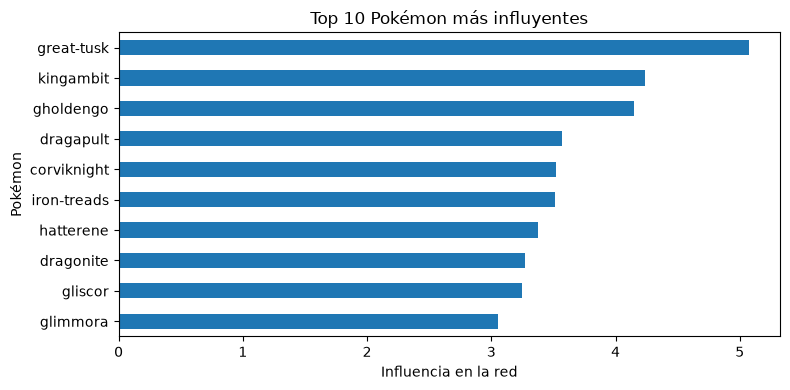

En los primeros lugares aparecen great-tusk, kingambit y gholdengo. Estos Pokémon quedan arriba porque no solo tienen conexiones en la red de compañeros, sino porque esas conexiones los acercan a otras piezas relevantes. En términos estratégicos, conviene leerlos como posibles ejes del formato: piezas que ayudan a unir equipos, formar cores o condicionar la preparación defensiva. El ranking no prueba que sean los mejores en combate, pero sí señala que ocupan posiciones estructurales en la red analizada.

In [4]:
run("CALL gds.graph.drop('teammates', false)")
run('''
CALL gds.graph.project(
  'teammates',
  'Pokemon',
  {
    TEAMMATE_OF: {
      orientation: 'UNDIRECTED'
    }
  }
)
''')
res = df('''
CALL gds.pageRank.stream('teammates') YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS p, score
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
RETURN p.identifier AS pokemon,
       round(score * 100000) / 100000.0 AS pagerank_competitivo,
       round(coalesce(u.usage, 0.0) * 100) / 100.0 AS uso_smogon
ORDER BY pagerank_competitivo DESC
LIMIT 20
''')
display(res)
if not res.empty:
    ax = res.head(10).sort_values('pagerank_competitivo').plot.barh(
        x='pokemon', y='pagerank_competitivo', legend=False, figsize=(8, 4)
    )
    ax.set_title('Top 10 Pokémon más influyentes')
    ax.set_xlabel('Influencia en la red')
    ax.set_ylabel('Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En los primeros lugares aparecen {nombres}. Estos Pokémon quedan arriba porque no solo tienen conexiones en la red de compañeros, "
        "sino porque esas conexiones los acercan a otras piezas relevantes. En términos estratégicos, conviene leerlos como posibles ejes del formato: "
        "piezas que ayudan a unir equipos, formar cores o condicionar la preparación defensiva. El ranking no prueba que sean los mejores en combate, "
        "pero sí señala que ocupan posiciones estructurales en la red analizada."
    ))


En este análisis, la influencia no debe entenderse simplemente como
popularidad o fuerza individual. Aquí se mide como centralidad dentro de la red
de compañeros de equipo: un Pokémon obtiene un valor más alto cuando aparece
conectado con muchas combinaciones relevantes y, especialmente, cuando sus
conexiones también involucran a otros Pokémon importantes dentro de la red. Por
eso, un valor mayor no significa necesariamente que ese Pokémon sea mejor en
batalla, sino que cumple un rol más estructural en los equipos observados.

La tabla y el gráfico permiten identificar piezas que ayudan a organizar el
metajuego competitivo. Si un Pokémon aparece con alta centralidad, puede ser
porque encaja en muchos equipos distintos, habilita estrategias comunes o forma
parte de cores usados con frecuencia. En términos prácticos, estos resultados
sirven para decidir qué amenazas conviene estudiar primero al preparar
respuestas defensivas o al analizar cómo se construyen equipos en el formato.

Esta medida depende de las relaciones cargadas desde Smogon y no incorpora por
sí sola detalles como objetos, EVs, movimientos específicos o decisiones dentro
de una partida. Por eso funciona como una señal inicial de influencia
estratégica, pero no reemplaza un análisis competitivo completo.


In [5]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       collect(DISTINCT m.identifier)[..5] AS movimientos_usados,
       collect(DISTINCT ab.identifier)[..3] AS habilidades_usadas,
       collect(DISTINCT it.identifier)[..3] AS objetos_usados
ORDER BY uso_smogon DESC
LIMIT 15
'''
res = df(query)
display(res)
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En esta tabla destacan {nombres}, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. "
        "La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso "
        "con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo."
    ))


,pokemon,uso_smogon,movimientos_usados,habilidades_usadas,objetos_usados
0,great-tusk,33.73,"[headlong-rush, knock-off, taunt, stealth-rock...",[protosynthesis],"[choice-band, heavy-duty-boots, leftovers]"
1,zamazenta,28.68,"[body-press, stone-edge, reflect, close-combat...",[dauntless-shield],"[heavy-duty-boots, leftovers, choice-scarf]"
2,gholdengo,27.63,"[psyshock, dazzling-gleam, hex, thunder-wave, ...",[good-as-gold],"[leftovers, shuca-berry, metal-coat]"
3,dragonite,25.35,"[dragon-claw, roost, outrage, low-kick, extrem...",[multiscale],"[loaded-dice, choice-band, silk-scarf]"
4,kingambit,25.27,"[low-kick, swords-dance, iron-head, sucker-pun...",[supreme-overlord],"[shuca-berry, black-glasses, leftovers]"
5,gliscor,19.39,"[earthquake, protect, stealth-rock, agility, t...",[poison-heal],[toxic-orb]
6,ting-lu,17.42,"[spikes, earthquake, protect, stealth-rock, ta...",[vessel-of-ruin],"[leftovers, rocky-helmet, red-card]"
7,kyurem,17.04,"[ice-beam, focus-blast, earth-power, blizzard,...",[pressure],"[heavy-duty-boots, choice-specs, loaded-dice]"
8,ogerpon-wellspring-mask,16.47,"[substitute, encore, taunt, synthesis, trailbl...",[water-absorb],[wellspring-mask]
9,dragapult,14.59,"[curse, draco-meteor, dragon-darts, quick-atta...","[clear-body, infiltrator]","[choice-band, choice-specs, air-balloon]"


En esta tabla destacan great-tusk, zamazenta y gholdengo, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo.

Esta tabla complementa la centralidad mostrando parte del kit competitivo de
los Pokémon más usados: movimientos, habilidades y objetos asociados. La idea es
pasar de "este Pokémon es importante" a una lectura más concreta sobre cómo
aporta valor dentro de un equipo. Un Pokémon puede ser central por su capacidad
de presionar, resistir, apoyar a compañeros o habilitar una secuencia común de
juego.

El resultado es útil porque permite conectar influencia con herramientas
observables. Si ciertos movimientos u objetos aparecen repetidamente, eso puede
orientar la preparación de respuestas defensivas y ayudar a entender qué recursos
definen el metajuego. Aun así, la tabla muestra una síntesis y no todos los
conjuntos posibles, por lo que debe leerse como una guía inicial y no como una
descripción completa de cada set competitivo.


### 4.2 Pokémon que podrían cumplir funciones parecidas

Jaccard es una forma simple de medir cuánto se parecen dos conjuntos. Aquí se
usa para comparar repertorios de movimientos. Además, se excluyen Pokémon de una
misma línea evolutiva y se agregan diferencias de estadísticas para evaluar si
la sustitución parece realista.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONAL MA

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=7, offset=738>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 738, 'line': 16, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONAL 

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=16, offset=747>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 747, 'line': 16, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONA

,pokemon_a,pokemon_b,movimientos_compartidos,similitud_jaccard,tipos_compartidos,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats
0,nidoqueen,nidoking,125,0.880,"[ground, poison]",505,505,0,9.67
1,clefable,wigglytuff,132,0.714,[fairy],483,435,48,23.00
2,clefairy,jigglypuff,128,0.707,[fairy],323,270,53,23.83
3,tyranitar,aggron,106,0.697,[rock],600,530,70,35.00
4,clefable,chansey,126,0.692,[],483,450,33,62.17
5,clefairy,wigglytuff,128,0.688,[fairy],323,435,112,24.67
6,clefable,jigglypuff,127,0.686,[fairy],483,270,213,42.17
7,aggron,rhyperior,102,0.680,[rock],530,535,5,24.17
8,clefairy,chansey,123,0.676,[],323,450,127,57.17
9,wigglytuff,chansey,118,0.659,[normal],435,450,15,54.17


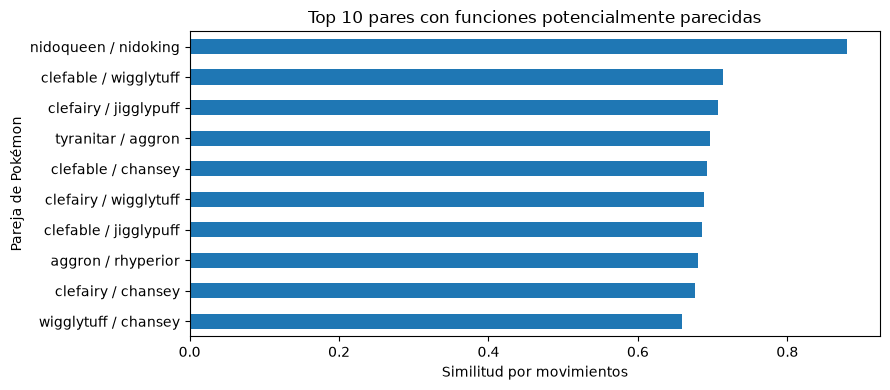

Entre los pares más altos aparecen nidoqueen / nidoking (Jaccard 0.88, diferencia BST 0); clefable / wigglytuff (Jaccard 0.714, diferencia BST 48); clefairy / jigglypuff (Jaccard 0.707, diferencia BST 53). Estos casos suben en la tabla porque comparten muchos movimientos y, al mismo tiempo, permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate.

In [6]:
query = '''MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size
ORDER BY movepool_size DESC
LIMIT 50
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movepool_size, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movepool_size, tipos:tipos, bst:bst, stats:stats}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 10
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
WITH a, b, inter, jaccard, diferencias_stats,
     (a.conexiones_team + b.conexiones_team) AS conexiones_team_total
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       [tipo IN a.tipos WHERE tipo IN b.tipos] AS tipos_compartidos,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats
ORDER BY similitud_jaccard DESC, movimientos_compartidos DESC
LIMIT 20
'''
res = df(query)
display(res)
if not res.empty:
    graf = res.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 pares con funciones potencialmente parecidas')
    ax.set_xlabel('Similitud por movimientos')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    top = res.head(3).copy()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (Jaccard {r.similitud_jaccard}, diferencia BST {r.diferencia_bst})"
        for r in top.itertuples()
    )
    display(Markdown(
        f"Entre los pares más altos aparecen {pares}. Estos casos suben en la tabla porque comparten muchos movimientos y, al mismo tiempo, "
        "permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande "
        "debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate."
    ))


La similitud entre Pokémon se calcula comparando sus repertorios de
movimientos. En términos simples, dos Pokémon aparecen más arriba cuando
comparten muchas herramientas posibles. Esto no significa que sean idénticos,
pero sí que podrían cumplir funciones parecidas, como aportar una cobertura
similar, usar movimientos de apoyo comparables o adaptarse a planes de equipo
relacionados.

La comparación de estadísticas agrega una segunda capa de lectura. El total de
estadísticas base (`bst_a` y `bst_b`) y las diferencias promedio ayudan a evaluar
si la sustitución es realista: dos Pokémon pueden aprender movimientos parecidos,
pero si uno tiene mucha más velocidad, bulk o poder ofensivo que el otro, la
alternativa puede funcionar peor en la práctica. También se excluyen evoluciones
y pre-evoluciones, porque normalmente no son sustitutos estratégicos útiles,
sino versiones relacionadas de una misma línea.

El resultado debe entenderse como una lista de candidatos para revisar, no como
una recomendación automática. Todavía faltan factores importantes como EVs,
naturalezas, objetos, habilidades específicas y rol dentro del equipo. El valor
del grafo está en reducir el espacio de búsqueda y proponer comparaciones
razonables que luego requieren juicio competitivo.


#### Sustitutos con mayor señal competitiva

La tabla anterior busca parecido funcional. Esta segunda tabla agrega una
exigencia adicional: al menos uno de los dos Pokémon debe tener presencia en la
capa competitiva, ya sea por uso en el formato o por conexiones en la red de
compañeros `TEAMMATE_OF`. Así se priorizan alternativas que no solo se parecen
por movimientos y estadísticas, sino que además tienen alguna señal de relevancia
en el grafo competitivo.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_size, 

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=7, offset=1167>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1167, 'line': 21, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_si

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=16, offset=1176>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1176, 'line': 21, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_

,pokemon_a,pokemon_b,pokemon_competitivo,movimientos_compartidos,similitud_jaccard,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats,conexiones_team_a,conexiones_team_b,conexiones_team_total
0,clefable,blissey,clefable / blissey,119,0.654,483,540,57,58.83,32,29,61
1,zapdos,moltres,zapdos / moltres,64,0.593,580,580,0,5.00,45,26,71
2,great-tusk,iron-treads,great-tusk / iron-treads,40,0.580,570,570,0,18.33,125,88,213
3,torkoal,heatran,torkoal / heatran,60,0.526,470,600,130,33.00,29,41,70
4,tyranitar,garchomp,tyranitar / garchomp,76,0.500,600,600,0,16.33,45,54,99
5,dragonite,tyranitar,dragonite / tyranitar,88,0.476,600,600,0,8.00,79,45,124
6,alomomola,primarina,alomomola / primarina,52,0.473,470,530,60,42.33,61,36,97
7,scizor,gliscor,scizor / gliscor,67,0.469,500,510,10,18.33,42,81,123
8,garchomp,excadrill,garchomp / excadrill,53,0.457,600,508,92,17.67,54,36,90
9,blaziken,hawlucha,blaziken / hawlucha,72,0.453,530,500,30,19.33,43,22,65


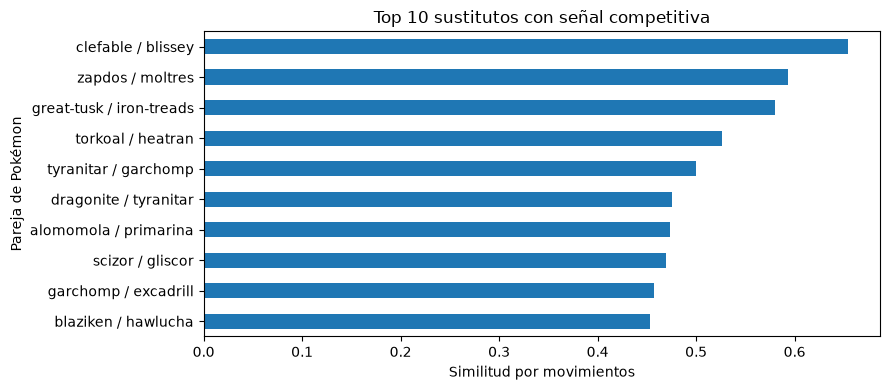

Con la restricción competitiva, los primeros pares son clefable / blissey (señal: clefable / blissey, conexiones 32+29); zapdos / moltres (señal: zapdos / moltres, conexiones 45+26); great-tusk / iron-treads (señal: great-tusk / iron-treads, conexiones 125+88). Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. Por eso estos pares son candidatos más cercanos a una discusión de construcción real.

In [7]:
query = '''MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size
OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)
WITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, moves, movepool_size, conexiones_team, coalesce(max(u.usage), 0.0) AS uso_smogon
ORDER BY conexiones_team DESC, uso_smogon DESC, movepool_size DESC
LIMIT 60
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movepool_size, conexiones_team, uso_smogon, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movepool_size, conexiones_team, uso_smogon, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movepool_size, tipos:tipos, bst:bst, stats:stats,
              conexiones_team:conexiones_team, uso_smogon:uso_smogon}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND (a.conexiones_team > 0 OR b.conexiones_team > 0 OR a.uso_smogon > 0 OR b.uso_smogon > 0)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 10
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
WITH a, b, inter, jaccard, diferencias_stats,
     a.conexiones_team + b.conexiones_team AS conexiones_team_total
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       CASE
         WHEN (a.conexiones_team > 0 OR a.uso_smogon > 0) AND (b.conexiones_team > 0 OR b.uso_smogon > 0)
           THEN a.p.identifier + ' / ' + b.p.identifier
         WHEN a.conexiones_team > 0 OR a.uso_smogon > 0 THEN a.p.identifier
         ELSE b.p.identifier
       END AS pokemon_competitivo,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats,
       a.conexiones_team AS conexiones_team_a,
       b.conexiones_team AS conexiones_team_b,
       conexiones_team_total AS conexiones_team_total
ORDER BY similitud_jaccard DESC, conexiones_team_total DESC, movimientos_compartidos DESC
LIMIT 20
'''
res_comp = df(query)
display(res_comp)
if not res_comp.empty:
    graf = res_comp.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 sustitutos con señal competitiva')
    ax.set_xlabel('Similitud por movimientos')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (señal: {r.pokemon_competitivo}, conexiones {r.conexiones_team_a}+{r.conexiones_team_b})"
        for r in res_comp.head(3).itertuples()
    )
    display(Markdown(
        f"Con la restricción competitiva, los primeros pares son {pares}. Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: "
        "al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. "
        "Por eso estos pares son candidatos más cercanos a una discusión de construcción real."
    ))


Esta segunda tabla no reemplaza a la primera: la complementa. La primera
permite descubrir parecidos funcionales amplios, mientras que esta filtra esos
parecidos hacia casos con mayor evidencia competitiva. Si un par mantiene alta
similitud por movimientos, diferencias razonables de estadísticas y además uno
de sus integrantes aparece conectado en la red de equipos, la comparación se
vuelve más interesante para discutir alternativas reales.

La lectura sigue requiriendo cautela. Las conexiones en `TEAMMATE_OF` indican
presencia relacional en el metajuego cargado, pero no explican por sí solas el
conjunto, el objeto ni el rol exacto. Por eso la tabla sirve para priorizar pares
que merecen revisión, no para afirmar automáticamente que un Pokémon reemplaza
al otro en cualquier equipo.


### 4.3 Perfiles ofensivos y defensivos de tipos

Esta sección separa los perfiles de un solo tipo y de dos tipos para que la
lectura sea más clara. La idea es distinguir cobertura ofensiva, es decir, a qué
tipos o combinaciones puede presionar un perfil, de cobertura defensiva, es
decir, qué ataques recibe como daño reducido, neutral o súper efectivo.

Antes de calcular estas métricas se revisa qué información existe en el grafo.
En este proyecto, `SUPER_EFFECTIVE` representa solo ventajas x2, mientras que
`EFFECTIVENESS.factor` contiene el cuadro completo de multiplicadores. Por eso
se pueden calcular daño normal x1, resistencias x0.5 y resistencias dobles
x0.25 sin inventar relaciones nuevas.


#### Cómo leer las columnas de cobertura

En las tablas siguientes, `cantidad_pokemon` sí indica cuántos Pokémon de la base
tienen ese perfil de tipo. En cambio, las columnas ofensivas no cuentan Pokémon:
cuentan tipos o combinaciones de tipos contra los que el perfil puede atacar con
cierta efectividad. Por ejemplo, `objetivos_ofensivos_x2` cuenta objetivos a los
que el perfil golpea de forma súper efectiva, mientras que
`combinaciones_objetivo_x4` cuenta combinaciones reales de dos tipos que pueden
recibir una presión híper efectiva.

Las columnas defensivas tampoco cuentan Pokémon. Resumen cuántos tipos ofensivos
representan amenazas, daño neutral o resistencias frente al perfil analizado.
`x2` significa súper efectivo, `x4` significa híper efectivo, `x0.5` indica
resistencia, `x0.25` indica resistencia doble y `x1` corresponde a daño normal o
neutral, no a resistencia. Finalmente, `balance_ajustado` es un puntaje
interpretativo para comparar perfiles de tipo; no es una métrica oficial del
juego ni reemplaza cálculos de daño reales.


In [8]:
efectividad = df('''
MATCH (atk:Type)-[r:EFFECTIVENESS]->(def:Type)
RETURN atk.identifier AS atacante, def.identifier AS defensor, r.factor AS factor
ORDER BY atacante, defensor
LIMIT 400
''')

tipos_pokemon = df('''
MATCH (p:Pokemon {is_default:true})-[:HAS_TYPE]->(t:Type)
RETURN p.identifier AS pokemon, t.identifier AS tipo
ORDER BY pokemon, tipo
LIMIT 3000
''')

factores = sorted(efectividad['factor'].dropna().astype(int).unique().tolist())
efectividad_completa = all(f in factores for f in [50, 100, 200])
display(pd.DataFrame([{
    'relacion': 'EFFECTIVENESS',
    'factores_observados': factores,
    'permite_x05_x025_x1': efectividad_completa
}]))

tipos = sorted(set(efectividad['atacante']) | set(efectividad['defensor']))
factor_map = {
    (r.atacante, r.defensor): int(r.factor) / 100.0
    for r in efectividad.itertuples()
}

def mult(atacante, defensor):
    return factor_map.get((atacante, defensor), 1.0)

nombres_cobertura = {
    'ofensiva_x2': 'objetivos_ofensivos_x2',
    'ofensiva_x4': 'combinaciones_objetivo_x4',
    'ofensiva_x1': 'objetivos_ofensivos_neutrales_x1',
    'debilidades_x2': 'amenazas_defensivas_x2',
    'debilidades_x4': 'amenazas_defensivas_x4',
    'amenazas_x4': 'tipos_amenaza_x4',
    'defensiva_x05': 'resistencias_defensivas_x05',
    'defensiva_x025': 'resistencias_defensivas_x025',
    'resistencias_x025': 'tipos_resistidos_x025',
    'defensiva_x1': 'amenazas_neutrales_x1',
}

def mostrar_columnas_claras(tabla, columnas, n=15):
    return tabla[columnas].head(n).rename(columns=nombres_cobertura)

tipos_por_pokemon = (
    tipos_pokemon.groupby('pokemon')['tipo']
    .apply(lambda s: sorted(set(s)))
    .reset_index(name='tipos')
)
tipos_por_pokemon['perfil_tipo'] = tipos_por_pokemon['tipos'].apply(lambda xs: ' / '.join(xs))

perfil_ejemplos = (
    tipos_por_pokemon.groupby('perfil_tipo')['pokemon']
    .apply(lambda s: ', '.join(list(s)[:5]))
    .to_dict()
)
perfil_cantidad = tipos_por_pokemon.groupby('perfil_tipo')['pokemon'].count().to_dict()
perfiles_individuales = sorted([xs[0] for xs in tipos_por_pokemon['tipos'] if len(xs) == 1])
perfiles_dobles = sorted({tuple(xs) for xs in tipos_por_pokemon['tipos'] if len(xs) == 2})

def ofensiva_basica(tipos_ofensivos):
    mejores = {defensor: max(mult(atk, defensor) for atk in tipos_ofensivos) for defensor in tipos}
    return {
        'ofensiva_x2': sum(1 for v in mejores.values() if v == 2.0),
        'ofensiva_x1': sum(1 for v in mejores.values() if v == 1.0),
    }

def defensiva(tipos_defensivos):
    valores = {}
    for atacante in tipos:
        total = 1.0
        for defensor in tipos_defensivos:
            total *= mult(atacante, defensor)
        valores[atacante] = total
    return valores

def ofensiva_x4_contra_combos(tipos_ofensivos):
    combos = []
    afectados = []
    for d1, d2 in perfiles_dobles:
        perfil = f'{d1} / {d2}'
        for atk in tipos_ofensivos:
            if mult(atk, d1) == 2.0 and mult(atk, d2) == 2.0:
                combos.append(perfil)
                afectados.extend(perfil_ejemplos.get(perfil, '').split(', '))
                break
    combos = sorted(set(c for c in combos if c))
    afectados = sorted(set(p for p in afectados if p))
    return combos, afectados

filas_ind = []
for perfil in sorted(set(perfiles_individuales)):
    off = ofensiva_basica([perfil])
    defs = defensiva([perfil])
    defensiva_x05 = sum(1 for v in defs.values() if v == 0.5)
    defensiva_x1 = sum(1 for v in defs.values() if v == 1.0)
    debilidades_x2 = sum(1 for v in defs.values() if v == 2.0)
    balance_tipo = off['ofensiva_x2'] + defensiva_x05 - debilidades_x2
    filas_ind.append({
        'perfil_tipo': perfil,
        'cantidad_pokemon': perfil_cantidad.get(perfil, 0),
        'ofensiva_x2': off['ofensiva_x2'],
        'ofensiva_x1': off['ofensiva_x1'],
        'defensiva_x05': defensiva_x05,
        'defensiva_x1': defensiva_x1,
        'debilidades_x2': debilidades_x2,
        'balance_tipo': balance_tipo,
        'balance_ajustado': balance_tipo,
        'ejemplos_pokemon': perfil_ejemplos.get(perfil, '')
    })

tabla_individual = pd.DataFrame(filas_ind).sort_values(
    ['balance_ajustado', 'ofensiva_x2', 'defensiva_x05'],
    ascending=False
).reset_index(drop=True)


,relacion,factores_observados,permite_x05_x025_x1
0,EFFECTIVENESS,"[0, 50, 100, 200]",True


#### 3.1 Perfiles de Pokémon de un solo tipo

En los Pokémon de un solo tipo, la lectura es directa: el perfil ofensivo depende
de lo que ese tipo puede golpear x2, mientras que el perfil defensivo depende de
qué tipos ofensivos le hacen daño reducido, neutral o súper efectivo. Aquí no se
incluyen debilidades x4 ni resistencias x0.25 porque esas situaciones aparecen
por combinación de dos tipos.


,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,objetivos_ofensivos_neutrales_x1,resistencias_defensivas_x05,amenazas_neutrales_x1,amenazas_defensivas_x2,balance_tipo,ejemplos_pokemon
0,steel,10,3,11,10,4,3,10,"copperajah, cufant, klang, klink, klinklang"
1,fire,36,4,10,6,9,3,7,"arcanine, braixen, charcadet, charmander, char..."
2,fighting,28,5,7,3,12,3,5,"clobbopus, conkeldurr, crabrawler, falinks, gr..."
3,water,74,3,12,4,12,2,5,"alomomola, arrokuda, barraskewda, basculin-red..."
4,poison,16,2,11,5,11,2,5,"arbok, ekans, garbodor, grimer, gulpin"
5,ground,17,5,10,2,12,3,4,"cubone, diglett, donphan, drilbur, dugtrio"
6,fairy,21,3,12,3,12,2,4,"alcremie, aromatisse, clefable, clefairy, cleffa"
7,electric,35,2,12,3,14,1,4,"ampharos, bellibolt, blitzle, boltund, eelektrik"
8,rock,17,4,11,4,9,5,3,"boldore, bonsly, cranidos, garganacl, gigalith"
9,bug,23,3,8,3,12,3,3,"accelgor, blipbug, burmy, cascoon, caterpie"


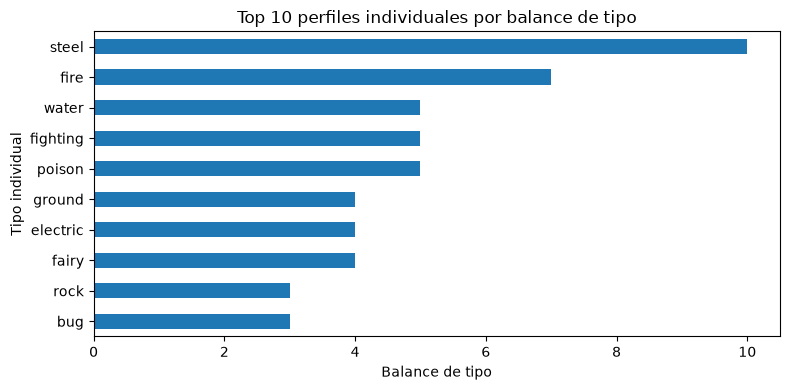

Entre los perfiles individuales mejor ubicados aparecen steel, fire y fighting. Estos tipos quedan arriba porque combinan buena cobertura x2, resistencias x0.5 y pocas debilidades x2. El balance de tipo no mide daño real ni sets concretos; funciona como una lectura resumida del intercambio entre presión ofensiva y seguridad defensiva. En una fila de esta tabla, `cantidad_pokemon` indica cuántos Pokémon tienen ese tipo, mientras que las columnas de cobertura resumen interacciones contra tipos: objetivos ofensivos, amenazas defensivas, resistencias y daño neutral.

In [9]:
columnas_individuales = [
    'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x1',
    'defensiva_x05', 'defensiva_x1',
    'debilidades_x2', 'balance_tipo',
    'ejemplos_pokemon'
]
display(mostrar_columnas_claras(tabla_individual, columnas_individuales, n=15))

if not tabla_individual.empty:
    ax = tabla_individual.head(10).sort_values('balance_tipo').plot.barh(
        x='perfil_tipo', y='balance_tipo', legend=False, figsize=(8, 4)
    )
    ax.set_title('Top 10 perfiles individuales por balance de tipo')
    ax.set_xlabel('Balance de tipo')
    ax.set_ylabel('Tipo individual')
    plt.tight_layout()
    plt.show()
    perfiles = lista_texto(tabla_individual['perfil_tipo'])
    display(Markdown(
        f"Entre los perfiles individuales mejor ubicados aparecen {perfiles}. Estos tipos quedan arriba porque combinan buena cobertura x2, "
        "resistencias x0.5 y pocas debilidades x2. El balance de tipo no mide daño real ni sets concretos; funciona como una lectura resumida "
        "del intercambio entre presión ofensiva y seguridad defensiva. En una fila de esta tabla, `cantidad_pokemon` indica cuántos Pokémon tienen ese tipo, "
        "mientras que las columnas de cobertura resumen interacciones contra tipos: objetivos ofensivos, amenazas defensivas, resistencias y daño neutral."
    ))


#### 3.2 Perfiles de Pokémon de dos tipos

Los Pokémon de dos tipos tienen una lectura más rica, pero también más riesgosa.
Una combinación puede ampliar la cobertura ofensiva y sumar resistencias, aunque
también puede crear debilidades x4 cuando un mismo tipo atacante es súper
efectivo contra ambos tipos defensivos. Por eso se agrega un balance ajustado
que premia cobertura y resistencias, pero penaliza con más fuerza las
vulnerabilidades dobles.


,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,combinaciones_objetivo_x4,amenazas_defensivas_x2,amenazas_defensivas_x4,tipos_amenaza_x4,resistencias_defensivas_x025,tipos_resistidos_x025,balance_ajustado,ejemplos_pokemon
0,fire / ground,2,8,14,1,1,water,0,,25,"camerupt, numel"
1,ground / steel,3,7,11,4,0,,1,rock,22,"excadrill, iron-treads, steelix"
2,ground / rock,9,8,14,4,2,"grass, water",1,poison,21,"geodude, golem, graveler, larvitar, onix"
3,flying / ground,3,8,12,1,1,ice,0,,21,"gligar, gliscor, landorus-incarnate"
4,ground / ice,3,9,15,5,0,,0,,20,"mamoswine, piloswine, swinub"
5,fighting / ground,1,8,14,6,0,,1,rock,20,great-tusk
6,fighting / fire,6,7,11,4,0,,1,bug,20,"blaziken, combusken, emboar, infernape, monferno"
7,ground / water,9,6,11,0,1,grass,0,,20,"barboach, gastrodon, marshtomp, palpitoad, qua..."
8,bug / ground,1,8,12,4,0,,0,,19,nincada
9,fire / steel,1,6,7,2,1,ground,5,"bug, fairy, grass, ice, steel",19,heatran


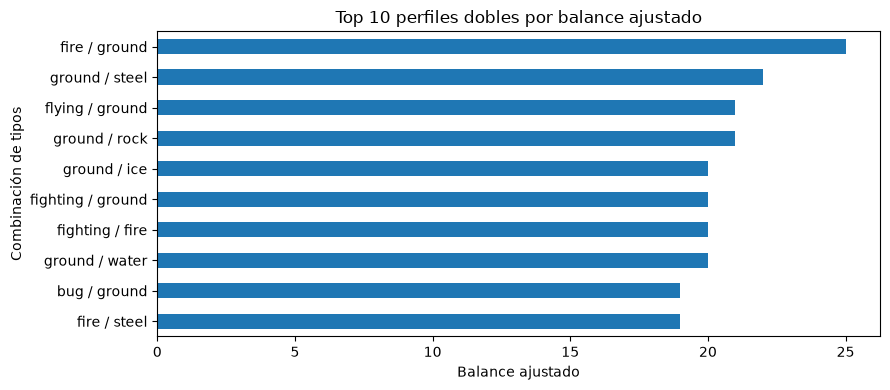

Entre las combinaciones dobles mejor ubicadas aparecen fire / ground, ground / steel y ground / rock. Estas combinaciones suelen quedar arriba porque suman cobertura ofensiva, resistencias útiles y pocas amenazas x4. Una debilidad x4 pesa más que una debilidad x2 porque marca un punto de entrada especialmente peligroso para el rival; por eso el balance ajustado la penaliza explícitamente. En una fila como `fire / ground`, `cantidad_pokemon` cuenta cuántos Pokémon tienen esa combinación, mientras que las demás columnas resumen interacciones de tipo: qué puede golpear, qué lo amenaza y si existen riesgos críticos x4 o resistencias fuertes x0.25.

In [10]:
filas_dobles = []
for t1, t2 in perfiles_dobles:
    perfil = f'{t1} / {t2}'
    off = ofensiva_basica([t1, t2])
    combos_x4, _ = ofensiva_x4_contra_combos([t1, t2])
    defs = defensiva([t1, t2])
    debilidades_x2 = sum(1 for v in defs.values() if v == 2.0)
    debilidades_x4 = sum(1 for v in defs.values() if v == 4.0)
    amenazas_x4 = sorted([atk for atk, v in defs.items() if v == 4.0])
    defensiva_x05 = sum(1 for v in defs.values() if v == 0.5)
    defensiva_x025 = sum(1 for v in defs.values() if v == 0.25)
    resistencias_x025 = sorted([atk for atk, v in defs.items() if v == 0.25])
    defensiva_x1 = sum(1 for v in defs.values() if v == 1.0)
    balance_tipo = off['ofensiva_x2'] - debilidades_x2
    balance_ajustado = (
        off['ofensiva_x2'] + len(combos_x4)
        - debilidades_x2 - debilidades_x4
        + defensiva_x05 + defensiva_x025
    )
    filas_dobles.append({
        'perfil_tipo': perfil,
        'cantidad_pokemon': perfil_cantidad.get(perfil, 0),
        'ofensiva_x2': off['ofensiva_x2'],
        'ofensiva_x4': len(combos_x4),
        'ofensiva_x1': off['ofensiva_x1'],
        'debilidades_x2': debilidades_x2,
        'debilidades_x4': debilidades_x4,
        'amenazas_x4': ', '.join(amenazas_x4),
        'defensiva_x05': defensiva_x05,
        'defensiva_x025': defensiva_x025,
        'resistencias_x025': ', '.join(resistencias_x025),
        'defensiva_x1': defensiva_x1,
        'balance_tipo': balance_tipo,
        'balance_ajustado': balance_ajustado,
        'ejemplos_pokemon': perfil_ejemplos.get(perfil, '')
    })

tabla_doble = pd.DataFrame(filas_dobles).sort_values(
    ['balance_ajustado', 'ofensiva_x4', 'debilidades_x4'],
    ascending=[False, False, True]
).reset_index(drop=True)

columnas_dobles = [
    'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x4',
    'debilidades_x2', 'debilidades_x4', 'amenazas_x4',
    'defensiva_x025', 'resistencias_x025',
    'balance_ajustado', 'ejemplos_pokemon'
]
display(mostrar_columnas_claras(tabla_doble, columnas_dobles, n=15))

if not tabla_doble.empty:
    ax = tabla_doble.head(10).sort_values('balance_ajustado').plot.barh(
        x='perfil_tipo', y='balance_ajustado', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 perfiles dobles por balance ajustado')
    ax.set_xlabel('Balance ajustado')
    ax.set_ylabel('Combinación de tipos')
    plt.tight_layout()
    plt.show()
    perfiles = lista_texto(tabla_doble['perfil_tipo'])
    display(Markdown(
        f"Entre las combinaciones dobles mejor ubicadas aparecen {perfiles}. Estas combinaciones suelen quedar arriba porque suman cobertura ofensiva, "
        "resistencias útiles y pocas amenazas x4. Una debilidad x4 pesa más que una debilidad x2 porque marca un punto de entrada especialmente peligroso "
        "para el rival; por eso el balance ajustado la penaliza explícitamente. En una fila como `fire / ground`, `cantidad_pokemon` cuenta cuántos Pokémon "
        "tienen esa combinación, mientras que las demás columnas resumen interacciones de tipo: qué puede golpear, qué lo amenaza y si existen riesgos críticos x4 "
        "o resistencias fuertes x0.25."
    ))


#### 3.3 Ventajas ofensivas x4 contra combinaciones reales

Una ventaja x4 aparece cuando un tipo ofensivo golpea súper efectivo a los dos
tipos de una combinación defensiva real. Esta vista es importante porque un tipo
puede no solo tener buena cobertura x2, sino además castigar de forma mucho más
fuerte a perfiles dobles concretos presentes en el grafo.


,tipo_ofensivo,combinaciones_x4,ejemplos_combinaciones,ejemplos_pokemon_afectados
0,ground,9,"electric / poison, electric / rock, electric /...","aggron, aron, bastiodon, carkol, coalossal"
1,fighting,6,"dark / ice, dark / normal, dark / rock, dark /...","aggron, amaura, aron, aurorus, bastiodon"
2,ice,6,"dragon / flying, dragon / grass, dragon / grou...","altaria, appletun, applin, dartrix, dipplin"
3,fire,5,"bug / grass, bug / ice, bug / steel, grass / i...","abomasnow, durant, escavalier, ferroseed, ferr..."
4,rock,5,"bug / fire, bug / flying, bug / ice, fire / fl...","articuno, beautifly, butterfree, centiskorch, ..."
5,bug,3,"dark / grass, dark / psychic, grass / psychic","brute-bonnet, cacturne, calyrex, celebi, exegg..."
6,fairy,3,"dark / dragon, dark / fighting, dragon / fighting","deino, guzzlord, hakamo-o, hydreigon, kommo-o"
7,flying,3,"bug / fighting, bug / grass, fighting / grass","breloom, buzzwole, chesnaught, heracross, leav..."
8,grass,3,"ground / rock, ground / water, rock / water","barbaracle, barboach, binacle, carracosta, cor..."
9,water,3,"fire / ground, fire / rock, ground / rock","camerupt, carkol, coalossal, geodude, golem"


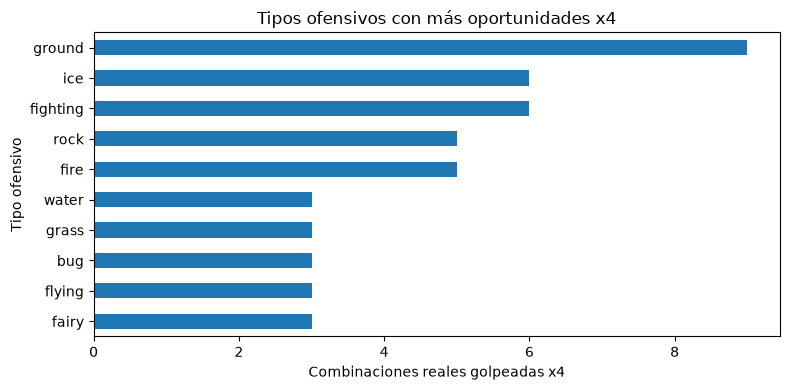

Los tipos ofensivos que más aparecen en esta vista son ground, fighting y ice. Su valor no viene solo de golpear x2 a tipos individuales, sino de amenazar combinaciones dobles reales con daño x4. Esto vuelve esas coberturas especialmente relevantes al preparar respuestas contra perfiles vulnerables.

In [11]:
filas_x4 = []
for atacante in tipos:
    combos = []
    afectados = []
    for d1, d2 in perfiles_dobles:
        if mult(atacante, d1) == 2.0 and mult(atacante, d2) == 2.0:
            perfil = f'{d1} / {d2}'
            combos.append(perfil)
            afectados.extend(perfil_ejemplos.get(perfil, '').split(', '))
    combos = sorted(set(combos))
    afectados = sorted(set(p for p in afectados if p))
    if combos:
        filas_x4.append({
            'tipo_ofensivo': atacante,
            'combinaciones_x4': len(combos),
            'ejemplos_combinaciones': ', '.join(combos[:5]),
            'ejemplos_pokemon_afectados': ', '.join(afectados[:5])
        })

tabla_x4 = pd.DataFrame(filas_x4).sort_values(
    ['combinaciones_x4', 'tipo_ofensivo'],
    ascending=[False, True]
).reset_index(drop=True)

display(tabla_x4.head(15))
if not tabla_x4.empty:
    ax = tabla_x4.head(10).sort_values('combinaciones_x4').plot.barh(
        x='tipo_ofensivo', y='combinaciones_x4', legend=False, figsize=(8, 4)
    )
    ax.set_title('Tipos ofensivos con más oportunidades x4')
    ax.set_xlabel('Combinaciones reales golpeadas x4')
    ax.set_ylabel('Tipo ofensivo')
    plt.tight_layout()
    plt.show()
    tipos_x4 = lista_texto(tabla_x4['tipo_ofensivo'])
    display(Markdown(
        f"Los tipos ofensivos que más aparecen en esta vista son {tipos_x4}. Su valor no viene solo de golpear x2 a tipos individuales, "
        "sino de amenazar combinaciones dobles reales con daño x4. Esto vuelve esas coberturas especialmente relevantes al preparar respuestas contra perfiles vulnerables."
    ))


#### 3.4 Resistencias dobles x0.25

También puede ocurrir lo contrario: si ambos tipos de una combinación resisten
el mismo tipo ofensivo, el daño recibido se aproxima a x0.25. Esa resistencia
doble puede ser estratégicamente valiosa porque permite entrar con más seguridad
frente a amenazas concretas. Este cálculo solo se reporta porque el grafo sí
contiene multiplicadores completos en `EFFECTIVENESS.factor`.


,perfil_tipo,resistencias_defensivas_x025,tipos_resistidos_x025,cantidad_pokemon,ejemplos_pokemon
0,fire / steel,5,"bug, fairy, grass, ice, steel",1,heatran
1,dragon / grass,3,"electric, grass, water",5,"appletun, applin, dipplin, flapple, hydrapple"
2,fire / poison,3,"bug, fairy, grass",3,"iron-moth, salandit, salazzle"
3,flying / poison,3,"bug, fighting, grass",3,"crobat, golbat, zubat"
4,poison / steel,3,"bug, fairy, grass",2,"revavroom, varoom"
5,fire / water,3,"fire, ice, steel",1,volcanion
6,bug / flying,2,"fighting, grass",13,"beautifly, butterfree, combee, ledian, ledyba"
7,bug / poison,2,"fighting, grass",12,"ariados, beedrill, dustox, kakuna, scolipede"
8,rock / steel,2,"flying, normal",7,"aggron, aron, bastiodon, lairon, probopass"
9,fire / flying,2,"bug, grass",6,"charizard, fletchinder, ho-oh, moltres, oricor..."


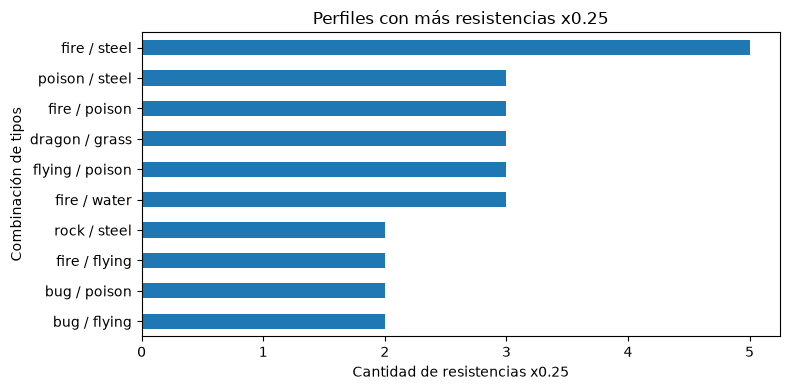

Perfiles como fire / steel, dragon / grass y fire / poison aparecen arriba porque ambos tipos resisten algunos de los mismos ataques. Esa doble resistencia no garantiza viabilidad por sí sola, pero sí puede convertir a estos perfiles en buenas respuestas defensivas frente a amenazas específicas.

In [12]:
if efectividad_completa:
    tabla_x025 = tabla_doble[tabla_doble['defensiva_x025'] > 0][[
        'perfil_tipo', 'defensiva_x025', 'resistencias_x025',
        'cantidad_pokemon', 'ejemplos_pokemon'
    ]].sort_values(['defensiva_x025', 'cantidad_pokemon'], ascending=False).reset_index(drop=True)
    display(mostrar_columnas_claras(tabla_x025, [
        'perfil_tipo', 'defensiva_x025', 'resistencias_x025',
        'cantidad_pokemon', 'ejemplos_pokemon'
    ], n=15))
    if not tabla_x025.empty:
        ax = tabla_x025.head(10).sort_values('defensiva_x025').plot.barh(
            x='perfil_tipo', y='defensiva_x025', legend=False, figsize=(8, 4)
        )
        ax.set_title('Perfiles con más resistencias x0.25')
        ax.set_xlabel('Cantidad de resistencias x0.25')
        ax.set_ylabel('Combinación de tipos')
        plt.tight_layout()
        plt.show()
        perfiles = lista_texto(tabla_x025['perfil_tipo'])
        display(Markdown(
            f"Perfiles como {perfiles} aparecen arriba porque ambos tipos resisten algunos de los mismos ataques. "
            "Esa doble resistencia no garantiza viabilidad por sí sola, pero sí puede convertir a estos perfiles en buenas respuestas defensivas frente a amenazas específicas."
        ))
else:
    display(Markdown(
        "El grafo actual permite observar relaciones de súper efectividad, pero no contiene información suficiente para calcular resistencias x0.5, "
        "resistencias x0.25 o neutralidades x1 de manera confiable. Por eso, esta parte se reporta como una limitación del análisis y como una extensión futura."
    ))


#### 3.5 Comparación general entre perfiles individuales y dobles

La comparación final junta perfiles individuales y dobles bajo una misma métrica
de balance ajustado. En los tipos individuales, el balance resume cobertura x2,
resistencias x0.5 y debilidades x2. En los tipos dobles, además se consideran
ventajas ofensivas x4, debilidades x4 y resistencias x0.25. La métrica no busca
ser un modelo perfecto de daño, sino una forma simple de ordenar perfiles para
discusión estratégica.


,categoria_tipo,perfil_tipo,cantidad_pokemon,objetivos_ofensivos_x2,combinaciones_objetivo_x4,objetivos_ofensivos_neutrales_x1,amenazas_defensivas_x2,amenazas_defensivas_x4,resistencias_defensivas_x05,resistencias_defensivas_x025,amenazas_neutrales_x1,balance_ajustado,ejemplos_pokemon
0,Doble,fire / ground,2,8,14,10,1,1,5,0,10,25,"camerupt, numel"
1,Doble,ground / steel,3,7,11,11,4,0,7,1,4,22,"excadrill, iron-treads, steelix"
2,Doble,ground / rock,9,8,14,10,4,2,4,1,6,21,"geodude, golem, graveler, larvitar, onix"
3,Doble,flying / ground,3,8,12,10,1,1,3,0,11,21,"gligar, gliscor, landorus-incarnate"
4,Doble,ground / ice,3,9,15,9,5,0,1,0,11,20,"mamoswine, piloswine, swinub"
5,Doble,fighting / ground,1,8,14,8,6,0,3,1,7,20,great-tusk
6,Doble,fighting / fire,6,7,11,11,4,0,5,1,8,20,"blaziken, combusken, emboar, infernape, monferno"
7,Doble,ground / water,9,6,11,11,0,1,4,0,12,20,"barboach, gastrodon, marshtomp, palpitoad, qua..."
8,Doble,bug / ground,1,8,12,9,4,0,3,0,10,19,nincada
9,Doble,fire / steel,1,6,7,10,2,1,4,5,5,19,heatran


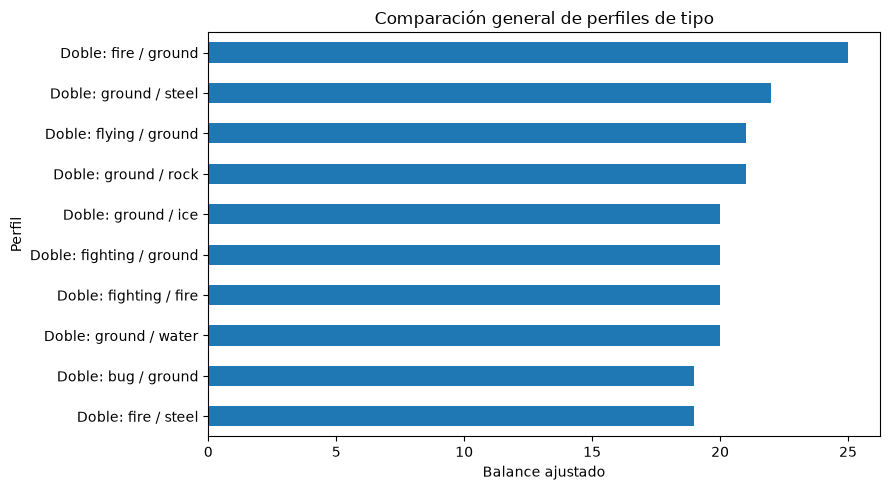

En la comparación general aparecen arriba perfiles como fire / ground, ground / steel y ground / rock. Los perfiles dobles pueden ganar por sumar resistencias y cobertura, pero también pueden caer si introducen amenazas x4. Los perfiles individuales suelen ser más simples de leer: no generan vulnerabilidades dobles, aunque tampoco acceden a las mismas sinergias defensivas u ofensivas de una combinación.

In [13]:
tabla_ind_comp = tabla_individual.assign(
    categoria_tipo='Individual',
    ofensiva_x4=0,
    debilidades_x4=0,
    defensiva_x025=0
)
tabla_dob_comp = tabla_doble.assign(categoria_tipo='Doble')

columnas_comparacion = [
    'categoria_tipo', 'perfil_tipo', 'cantidad_pokemon',
    'ofensiva_x2', 'ofensiva_x4', 'ofensiva_x1',
    'debilidades_x2', 'debilidades_x4',
    'defensiva_x05', 'defensiva_x025', 'defensiva_x1',
    'balance_ajustado', 'ejemplos_pokemon'
]

tabla_general = pd.concat([
    tabla_ind_comp[columnas_comparacion],
    tabla_dob_comp[columnas_comparacion]
], ignore_index=True).sort_values(
    ['balance_ajustado', 'ofensiva_x4', 'debilidades_x4'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(mostrar_columnas_claras(tabla_general, columnas_comparacion, n=20))
if not tabla_general.empty:
    graf = tabla_general.head(10).copy()
    graf['perfil'] = graf['categoria_tipo'] + ': ' + graf['perfil_tipo']
    ax = graf.sort_values('balance_ajustado').plot.barh(
        x='perfil', y='balance_ajustado', legend=False, figsize=(9, 5)
    )
    ax.set_title('Comparación general de perfiles de tipo')
    ax.set_xlabel('Balance ajustado')
    ax.set_ylabel('Perfil')
    plt.tight_layout()
    plt.show()
    mejores = lista_texto(tabla_general['perfil_tipo'])
    display(Markdown(
        f"En la comparación general aparecen arriba perfiles como {mejores}. Los perfiles dobles pueden ganar por sumar resistencias y cobertura, "
        "pero también pueden caer si introducen amenazas x4. Los perfiles individuales suelen ser más simples de leer: no generan vulnerabilidades dobles, "
        "aunque tampoco acceden a las mismas sinergias defensivas u ofensivas de una combinación."
    ))


### 4.4 Grupos o cores que aparecen juntos en equipos

Louvain agrupa Pokémon que aparecen conectados de forma densa en la red de
compañeros. En lenguaje simple, Louvain detecta grupos de Pokémon que tienden a
conectarse entre sí.


,comunidad,nombre_core,criterio_nombre,tamaño,uso_promedio,muestra_pokemon,tipos_frecuentes_en_muestra,movimientos_frecuentes_en_muestra,habilidades_frecuentes_en_muestra,objetos_frecuentes_en_muestra
0,1195,Core de sol / fuego-planta,tipos frecuentes: fire/grass; movimientos asoc...,22,5.67,"[primeape, exeggcute, girafarig, forretress, s...","[fighting, psychic, grass, normal, steel, bug]","[block, synthesis, leech-seed, skill-swap, psy...","[harvest, sap-sipper, sturdy, own-tempo, techn...","[colbur-berry, lum-berry, mind-plate, leftover..."
1,1261,Core de sol / fuego-planta,tipos frecuentes: fire/grass; movimientos asoc...,29,5.54,"[venusaur, charizard, ninetales, ursaring, tor...","[poison, grass, fire, flying, normal, rock]","[giga-drain, earth-power, growth, sludge-bomb,...","[chlorophyll, solar-power, blaze, drought, stu...","[life-orb, leftovers, focus-sash, heavy-duty-b..."
2,487,Core de lluvia / agua,tipos frecuentes: water; movimientos de agua o...,43,3.89,"[gyarados, lapras, ditto, blaziken, gardevoir,...","[flying, water, ice, normal, fire, fighting]","[scale-shot, waterfall, substitute, crunch, ic...","[moxie, intimidate, water-absorb, imposter, sp...","[leftovers, expert-belt, loaded-dice, heavy-du..."
3,1022,Core Trick Room,presencia de trick-room; movimientos frecuente...,37,3.22,"[porygon2, tyranitar, hariyama, salamence, inf...","[normal, rock, dark, fighting, flying, dragon]","[hyper-beam, trick-room, foul-play, discharge,...","[trace, download, sand-stream, guts, intimidate]","[eviolite, assault-vest, heavy-duty-boots, cho..."
4,778,Core de lluvia / agua,tipos frecuentes: water; movimientos de agua o...,33,2.98,"[golduck, poliwrath, zapdos, politoed, kingdra...","[water, fighting, flying, electric, dragon, fire]","[nasty-plot, hydro-pump, ice-beam, vacuum-wave...","[swift-swim, water-absorb, pressure, static, d...","[life-orb, rocky-helmet, covert-cloak, sitrus-..."
5,380,Core de setup ofensivo,movimientos de aumento de estadísticas; movimi...,25,2.77,"[heracross, skarmory, latios, gastrodon, misma...","[bug, fighting, flying, steel, psychic, dragon]","[trailblaze, earthquake, knock-off, facade, cl...","[moxie, guts, sturdy, levitate, sticky-hold]","[choice-scarf, flame-orb, heavy-duty-boots, le..."
6,987,Core de lluvia / agua,tipos frecuentes: water; movimientos de agua o...,25,2.39,"[tentacruel, cloyster, chansey, quagsire, blis...","[water, poison, ice, normal, ground, dragon]","[knock-off, poison-jab, sludge-bomb, acid-spra...","[rain-dish, liquid-ooze, clear-body, skill-lin...","[heavy-duty-boots, leftovers, assault-vest, fo..."
7,608,Core de lluvia / agua,tipos frecuentes: water; movimientos de agua o...,47,1.87,"[blastoise, raichu, clefable, vileplume, slowb...","[water, electric, fairy, poison, grass, psychic]","[rapid-spin, shell-smash, weather-ball, ice-be...","[torrent, rain-dish, lightning-rod, unaware, m...","[heavy-duty-boots, life-orb, assault-vest, whi..."


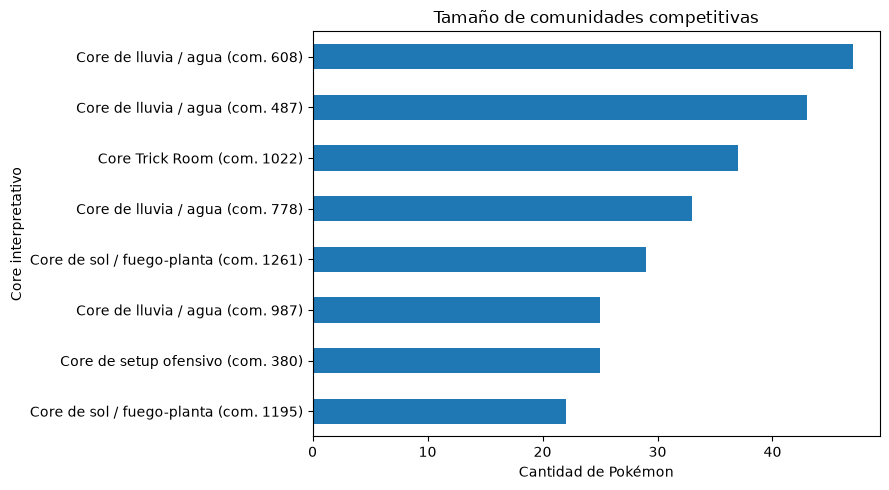

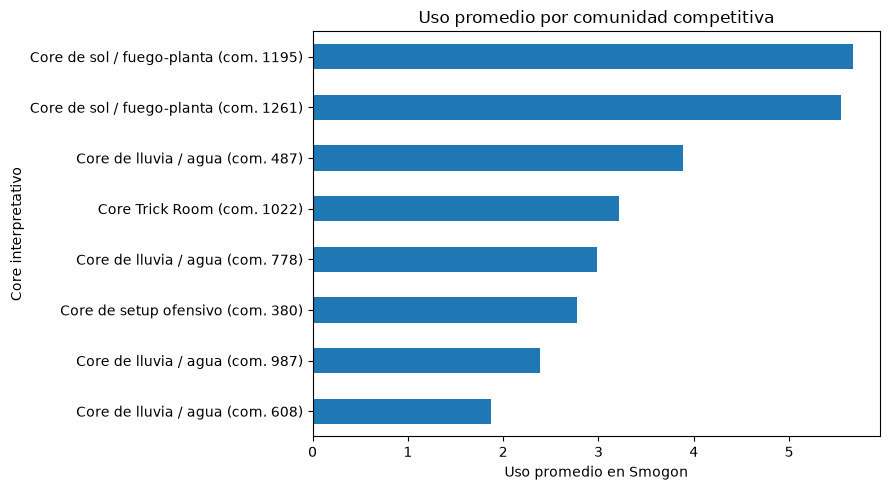

La comunidad 1195 se etiqueta como **Core de sol / fuego-planta** a partir de una muestra que incluye primeape, exeggcute, girafarig y forretress. El criterio usado fue: tipos frecuentes: fire/grass; movimientos asociados a sol o fuego-planta; movimientos frecuentes: block, synthesis, psychic-noise, stored-power; tipos frecuentes: bug, normal, grass, psychic; habilidades observadas: sturdy, own-tempo, technician; objetos observados: mind-plate, leftovers, colbur-berry. Esta etiqueta resume evidencia visible en la tabla, pero no debe leerse como una categoría oficial.

In [14]:
res = df('''
CALL gds.louvain.stream('teammates') YIELD nodeId, communityId
WITH communityId, gds.util.asNode(nodeId) AS p
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
RETURN communityId AS comunidad,
       count(DISTINCT p) AS tamaño,
       round(avg(coalesce(u.usage, 0.0)) * 100) / 100.0 AS uso_promedio,
       collect(DISTINCT p.identifier)[..10] AS muestra_pokemon,
       collect(DISTINCT t.identifier)[..6] AS tipos_frecuentes_en_muestra,
       collect(DISTINCT m.identifier)[..8] AS movimientos_frecuentes_en_muestra,
       collect(DISTINCT ab.identifier)[..5] AS habilidades_frecuentes_en_muestra,
       collect(DISTINCT it.identifier)[..5] AS objetos_frecuentes_en_muestra
ORDER BY uso_promedio DESC, tamaño DESC
LIMIT 8
''')

def nombrar_core(fila):
    tipos = set(fila.get('tipos_frecuentes_en_muestra', []) or [])
    movimientos = set(fila.get('movimientos_frecuentes_en_muestra', []) or [])
    habilidades = set(fila.get('habilidades_frecuentes_en_muestra', []) or [])
    objetos = set(fila.get('objetos_frecuentes_en_muestra', []) or [])

    lluvia = {'rain-dance', 'hydro-pump', 'surf', 'waterfall', 'aqua-jet'}
    sol = {'sunny-day', 'solar-beam', 'synthesis', 'flamethrower', 'fire-blast'}
    desgaste = {'protect', 'leech-seed', 'toxic', 'will-o-wisp', 'recover', 'roost', 'synthesis', 'wish', 'soft-boiled'}
    setup = {'swords-dance', 'nasty-plot', 'dragon-dance', 'calm-mind', 'bulk-up', 'quiver-dance', 'shell-smash'}
    control = {'rapid-spin', 'defog', 'stealth-rock', 'spikes', 'toxic-spikes', 'knock-off', 'taunt', 'encore'}
    velocidad = {'u-turn', 'volt-switch', 'agility', 'trailblaze', 'rapid-spin', 'dragon-dance'}

    if 'trick-room' in movimientos:
        nombre = 'Core Trick Room'
        base = 'presencia de trick-room'
    elif movimientos & lluvia and 'water' in tipos:
        nombre = 'Core de lluvia / agua'
        base = 'tipos frecuentes: water; movimientos de agua o lluvia'
    elif movimientos & sol and ({'fire', 'grass'} & tipos):
        nombre = 'Core de sol / fuego-planta'
        base = 'tipos frecuentes: fire/grass; movimientos asociados a sol o fuego-planta'
    elif movimientos & desgaste:
        nombre = 'Core defensivo de desgaste'
        base = 'movimientos de recuperación/desgaste'
    elif movimientos & setup:
        nombre = 'Core de setup ofensivo'
        base = 'movimientos de aumento de estadísticas'
    elif movimientos & control:
        nombre = 'Core de soporte y control'
        base = 'movimientos de control, peligros de entrada o limpieza'
    elif movimientos & velocidad:
        nombre = 'Core de velocidad / presión ofensiva'
        base = 'movimientos de pivoteo, velocidad o presión'
    elif 'water' in tipos:
        nombre = 'Core basado en tipos agua'
        base = 'muestra con varios Pokémon de tipo water'
    elif {'fire', 'grass'} & tipos:
        nombre = 'Core mixto fuego-planta'
        base = 'presencia de tipos fire/grass en la muestra'
    else:
        nombre = 'Core mixto con soporte'
        base = 'mezcla de Pokémon y herramientas sin etiqueta dominante clara'

    partes = [base]
    if movimientos:
        partes.append('movimientos frecuentes: ' + ', '.join(list(movimientos)[:4]))
    if tipos:
        partes.append('tipos frecuentes: ' + ', '.join(list(tipos)[:4]))
    if habilidades:
        partes.append('habilidades observadas: ' + ', '.join(list(habilidades)[:3]))
    if objetos:
        partes.append('objetos observados: ' + ', '.join(list(objetos)[:3]))
    return pd.Series({'nombre_core': nombre, 'criterio_nombre': '; '.join(partes)})

if not res.empty:
    res = pd.concat([res, res.apply(nombrar_core, axis=1)], axis=1)
    res['nombre_grafico'] = res.apply(
        lambda r: f"{r['nombre_core']} (com. {r['comunidad']})",
        axis=1
    )

columnas_core = [
    'comunidad', 'nombre_core', 'criterio_nombre', 'tamaño', 'uso_promedio',
    'muestra_pokemon', 'tipos_frecuentes_en_muestra',
    'movimientos_frecuentes_en_muestra',
    'habilidades_frecuentes_en_muestra', 'objetos_frecuentes_en_muestra'
]
if not res.empty:
    display(res[columnas_core])
    ax = res.sort_values('tamaño').plot.barh(
        x='nombre_grafico', y='tamaño', legend=False, figsize=(9, 5)
    )
    ax.set_title('Tamaño de comunidades competitivas')
    ax.set_xlabel('Cantidad de Pokémon')
    ax.set_ylabel('Core interpretativo')
    plt.tight_layout()
    plt.show()

    ax = res.sort_values('uso_promedio').plot.barh(
        x='nombre_grafico', y='uso_promedio', legend=False, figsize=(9, 5)
    )
    ax.set_title('Uso promedio por comunidad competitiva')
    ax.set_xlabel('Uso promedio en Smogon')
    ax.set_ylabel('Core interpretativo')
    plt.tight_layout()
    plt.show()

    fila = res.iloc[0]
    muestra = lista_texto(fila['muestra_pokemon'], max_items=4)
    display(Markdown(
        f"La comunidad {fila['comunidad']} se etiqueta como **{fila['nombre_core']}** a partir de una muestra que incluye {muestra}. "
        f"El criterio usado fue: {fila['criterio_nombre']}. Esta etiqueta resume evidencia visible en la tabla, pero no debe leerse como una categoría oficial."
    ))
else:
    display(res)


El algoritmo entrega comunidades numeradas, pero esos números no tienen
significado competitivo por sí solos. Por eso, en esta versión se conserva la
columna `comunidad` como identificador técnico y se agrega `nombre_core` como
una etiqueta interpretativa. Ese nombre se construye a partir de la evidencia
disponible en la tabla: Pokémon representativos, tipos observados, movimientos
frecuentes y, cuando aparecen, habilidades u objetos. Así, una comunidad deja de
ser solo un número interno y pasa a ser una hipótesis más fácil de leer.

Estas etiquetas no deben entenderse como una clasificación oficial del
metajuego. Funcionan como una ayuda de interpretación: permiten pasar de una
comunidad anónima a una posible lectura sobre su función estratégica, como
soporte, desgaste, presión ofensiva, control o afinidad por ciertos tipos. Si la
evidencia no es suficiente para una etiqueta fuerte, el nombre se mantiene
prudente, por ejemplo como core mixto o core general con soporte.

El gráfico de tamaño muestra cuántos Pokémon agrupa cada comunidad, mientras que
el gráfico de uso promedio permite comparar esa cantidad con una señal de
presencia competitiva. Una comunidad grande no siempre es la más influyente, y
una comunidad de alto uso promedio puede estar formada por menos piezas pero más
presentes en el formato. Para confirmar que un grupo corresponde a un core real
habría que revisar conjuntos de movimientos, objetos, EVs, roles concretos y
contexto competitivo.


### 4.5 Cadenas que explican por qué un Pokémon encaja

Las cadenas explicativas conectan una pieza con recursos y contexto competitivo.
La idea no es listar todas las combinaciones posibles, sino mostrar ejemplos
representativos de cómo el grafo une Pokémon, movimientos, tipos de movimiento,
compañeros frecuentes y señales de uso. Para que el resultado sea más útil, se
limita la repetición de un mismo Pokémon y se priorizan cadenas diversas.


#### 5.1 Cadenas explicativas representativas

Cada fila de esta tabla resume una cadena principal para un Pokémon distinto.
Los movimientos y compañeros aparecen como listas, no como filas separadas, para
evitar que una sola pieza muy usada domine todo el análisis.


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=8, column=1, offset=206>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 206, 'line': 8, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, u\nORDER BY u.usage DESC\nLIMIT 12\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)\nWITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon\nCALL {\n  WITH p\n  MATCH (p)-[:RUNS_MOVE]->(m:Move)\n  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)\n  RETURN collect(DISTINCT m.i

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL (p) { ... }', position=<SummaryInputPosition line=15, column=1, offset=451>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 451, 'line': 15, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, u\nORDER BY u.usage DESC\nLIMIT 12\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)\nWITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon\nCALL {\n  WITH p\n  MATCH (p)-[:RUNS_MOVE]->(m:Move)\n  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)\n  RETURN collect(DISTINCT m

,pokemon,uso_smogon,tipos_pokemon,movimientos_representativos,tipos_de_movimientos,companeros_frecuentes,co_uso_promedio,co_uso_maximo,cadena_explicativa,lectura_estrategica
0,great-tusk,33.73,"[ground, fighting]","[headlong-rush, knock-off, taunt, stealth-rock...","[ground, dark, rock, normal, fighting]","[gholdengo, kingambit, slowking-galar]",1303.80,1604.8,great-tusk -> headlong-rush / knock-off / taun...,"Conecta herramientas como headlong-rush, knock..."
1,zamazenta,28.68,[fighting],"[body-press, stone-edge, reflect, close-combat...","[fighting, rock, psychic, steel, normal]","[gholdengo, gliscor, samurott-hisui]",1072.30,1399.4,zamazenta -> body-press / stone-edge / reflect...,"Conecta herramientas como body-press, stone-ed..."
2,gholdengo,27.63,"[ghost, steel]","[psyshock, dazzling-gleam, hex, thunder-wave, ...","[psychic, fairy, ghost, electric, normal]","[dragonite, great-tusk, zamazenta]",1730.13,2186.2,gholdengo -> psyshock / dazzling-gleam / hex /...,"Conecta herramientas como psyshock, dazzling-g..."
3,dragonite,25.35,"[flying, dragon]","[dragon-claw, roost, outrage, low-kick, extrem...","[dragon, flying, fighting, normal, ice]","[gholdengo, ting-lu, pecharunt]",1329.97,2186.2,dragonite -> dragon-claw / roost / outrage / l...,"Conecta herramientas como dragon-claw, roost, ..."
4,kingambit,25.27,"[dark, steel]","[low-kick, swords-dance, iron-head, sucker-pun...","[fighting, normal, steel, dark]","[great-tusk, ogerpon-wellspring-mask, kyurem]",1022.27,1430.9,kingambit -> low-kick / swords-dance / iron-he...,"Conecta herramientas como low-kick, swords-dan..."
5,gliscor,19.39,"[flying, ground]","[earthquake, protect, stealth-rock, agility, t...","[ground, normal, rock, psychic, poison]","[zamazenta, blissey, gholdengo]",1028.80,1218.2,gliscor -> earthquake / protect / stealth-rock...,"Conecta herramientas como earthquake, protect,..."
6,ting-lu,17.42,"[ground, dark]","[spikes, earthquake, protect, stealth-rock, ta...","[ground, normal, rock, dark, steel]","[dragonite, gholdengo, kingambit]",971.43,1262.5,ting-lu -> spikes / earthquake / protect / ste...,"Conecta herramientas como spikes, earthquake, ..."
7,kyurem,17.04,"[dragon, ice]","[ice-beam, focus-blast, earth-power, blizzard,...","[ice, fighting, ground, dragon, rock]","[kingambit, slowking-galar, landorus-therian]",587.07,753.0,kyurem -> ice-beam / focus-blast / earth-power...,"Conecta herramientas como ice-beam, focus-blas..."
8,ogerpon-wellspring-mask,16.47,"[water, grass]","[substitute, encore, taunt, synthesis, trailbl...","[normal, dark, grass, ground, fairy]","[kingambit, great-tusk, gholdengo]",805.77,882.9,ogerpon-wellspring-mask -> substitute / encore...,"Conecta herramientas como substitute, encore, ..."
9,dragapult,14.59,"[ghost, dragon]","[curse, draco-meteor, dragon-darts, quick-atta...","[ghost, dragon, normal, electric, fire]","[landorus-therian, ting-lu, dragonite]",302.07,313.1,dragapult -> curse / draco-meteor / dragon-dar...,"Conecta herramientas como curse, draco-meteor,..."


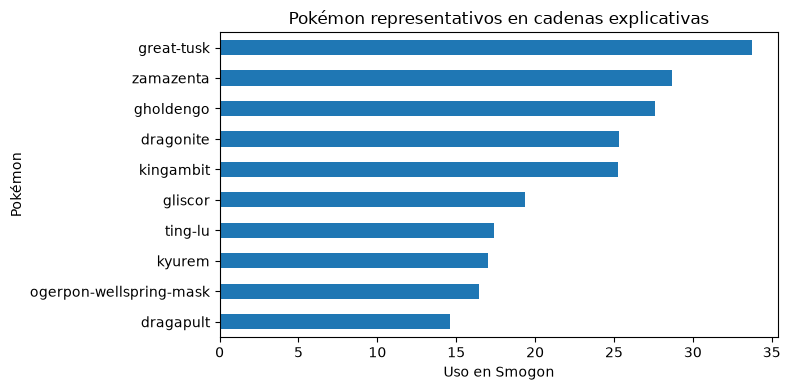

La tabla resume cadenas para Pokémon distintos, como great-tusk, zamazenta y gholdengo. En vez de expandir cada movimiento y cada compañero en filas separadas, cada fila reúne una muestra de herramientas y vínculos competitivos. Esto permite comparar funciones sin que una sola pieza de alto uso ocupe casi toda la salida.

In [15]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, u
ORDER BY u.usage DESC
LIMIT 12
OPTIONAL MATCH (p)-[:HAS_TYPE]->(tp:Type)
WITH p, u, collect(DISTINCT tp.identifier)[..2] AS tipos_pokemon
CALL {
  WITH p
  MATCH (p)-[:RUNS_MOVE]->(m:Move)
  OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)
  RETURN collect(DISTINCT m.identifier)[..5] AS movimientos_representativos,
         collect(DISTINCT mt.identifier)[..5] AS tipos_de_movimientos
}
CALL {
  WITH p
  MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
  WITH aliado, max(coalesce(tm.pct, 0.0)) AS co_uso
  ORDER BY co_uso DESC
  LIMIT 3
  RETURN collect(aliado.identifier) AS companeros_frecuentes,
         round(avg(co_uso) * 100) / 100.0 AS co_uso_promedio,
         round(max(co_uso) * 100) / 100.0 AS co_uso_maximo
}
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       tipos_pokemon,
       movimientos_representativos,
       tipos_de_movimientos,
       companeros_frecuentes,
       co_uso_promedio,
       co_uso_maximo
ORDER BY uso_smogon DESC
LIMIT 12
'''
res_cadenas = df(query)

def lectura_cadena(fila):
    movimientos = fila['movimientos_representativos'] or []
    tipos_mov = fila['tipos_de_movimientos'] or []
    companeros = fila['companeros_frecuentes'] or []
    mov_txt = ', '.join(movimientos[:3]) if movimientos else 'movimientos no detallados'
    tipos_txt = ', '.join(tipos_mov[:3]) if tipos_mov else 'tipos no detallados'
    comp_txt = ', '.join(companeros[:3]) if companeros else 'compañeros no detallados'
    return (
        f"Conecta herramientas como {mov_txt} ({tipos_txt}) con compañeros frecuentes como {comp_txt}. "
        "La cadena sugiere una función posible dentro de equipos reales, pero no demuestra por sí sola un conjunto exacto."
    )

if not res_cadenas.empty:
    res_cadenas['cadena_explicativa'] = res_cadenas.apply(
        lambda r: (
            f"{r['pokemon']} -> {' / '.join(r['movimientos_representativos'] or [])} "
            f"-> {' / '.join(r['tipos_de_movimientos'] or [])} "
            f"-> {' / '.join(r['companeros_frecuentes'] or [])}"
        ),
        axis=1
    )
    res_cadenas['lectura_estrategica'] = res_cadenas.apply(lectura_cadena, axis=1)

display(res_cadenas)
if not res_cadenas.empty:
    ax = res_cadenas.head(10).sort_values('uso_smogon').plot.barh(
        x='pokemon', y='uso_smogon', legend=False, figsize=(8, 4)
    )
    ax.set_title('Pokémon representativos en cadenas explicativas')
    ax.set_xlabel('Uso en Smogon')
    ax.set_ylabel('Pokémon')
    plt.tight_layout()
    plt.show()
    ejemplos = lista_texto(res_cadenas['pokemon'])
    display(Markdown(
        f"La tabla resume cadenas para Pokémon distintos, como {ejemplos}. En vez de expandir cada movimiento y cada compañero en filas separadas, "
        "cada fila reúne una muestra de herramientas y vínculos competitivos. Esto permite comparar funciones sin que una sola pieza de alto uso ocupe casi toda la salida."
    ))


La tabla no debe leerse como una receta exacta de equipo, sino como una
explicación de conexiones. Para cada Pokémon, el grafo permite unir su presencia
competitiva con algunos movimientos relevantes y con compañeros que aparecen
asociados en la red. Esto ayuda a pasar de una pregunta simple, como qué
movimientos aprende o usa un Pokémon, a una pregunta más estratégica: qué tipo
de función puede cumplir y con qué otras piezas suele conectarse.

Los movimientos listados no implican necesariamente un conjunto competitivo completo.
Funcionan como evidencia disponible en el grafo para describir capacidades
posibles, mientras que los compañeros frecuentes aportan contexto de equipo.
Para confirmar un conjunto real habría que revisar objeto, EVs, habilidad,
formato y uso concreto en partidas.


#### 5.2 Ejemplos de cadenas concretas

La tabla siguiente baja un nivel de detalle y muestra ejemplos específicos de
Pokémon, movimiento y compañero frecuente. Se limita la repetición para mantener
diversidad: primero se ordenan las posibles cadenas por uso y co-uso, y luego se
conserva como máximo una fila principal por Pokémon.


In [16]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, u
ORDER BY u.usage DESC
LIMIT 18
MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       m.identifier AS movimiento_usado,
       mt.identifier AS tipo_del_movimiento,
       aliado.identifier AS companero_frecuente,
       round(coalesce(tm.pct, 0.0) * 100) / 100.0 AS co_uso
ORDER BY uso_smogon DESC, co_uso DESC
LIMIT 80
'''
ejemplos_cadenas = df(query)
columnas_ejemplos = ['pokemon', 'movimiento_usado', 'tipo_del_movimiento',
                    'companero_frecuente', 'co_uso', 'explicacion_cadena']
if not ejemplos_cadenas.empty:
    ejemplos_cadenas = (
        ejemplos_cadenas
        .dropna(subset=['movimiento_usado', 'companero_frecuente'])
        .drop_duplicates(subset=['pokemon'])
        .head(8)
        .reset_index(drop=True)
    )
    ejemplos_cadenas['explicacion_cadena'] = ejemplos_cadenas.apply(
        lambda r: (
            f"{r['pokemon']} se conecta con {r['movimiento_usado']} de tipo {r['tipo_del_movimiento']} "
            f"y con {r['companero_frecuente']} como compañero frecuente. Esto sugiere una relación entre herramienta, cobertura o utilidad y contexto competitivo."
        ),
        axis=1
    )
else:
    ejemplos_cadenas = pd.DataFrame(columns=columnas_ejemplos)
display(ejemplos_cadenas[columnas_ejemplos])
if not ejemplos_cadenas.empty:
    ejemplos = "; ".join(
        f"{r['pokemon']} -> {r['movimiento_usado']} -> {r['companero_frecuente']}"
        for _, r in ejemplos_cadenas.head(2).iterrows()
    )
    display(Markdown(
        f"Ejemplos como {ejemplos} muestran cómo una cadena concreta puede justificar una hipótesis estratégica. "
        "No se afirma causalidad: el grafo no prueba que el movimiento cause la asociación con el compañero, pero sí muestra que esas entidades aparecen conectadas en la capa competitiva."
    ))


,pokemon,movimiento_usado,tipo_del_movimiento,companero_frecuente,co_uso,explicacion_cadena
0,great-tusk,body-press,fighting,gholdengo,1604.8,great-tusk se conecta con body-press de tipo f...


Ejemplos como great-tusk -> body-press -> gholdengo muestran cómo una cadena concreta puede justificar una hipótesis estratégica. No se afirma causalidad: el grafo no prueba que el movimiento cause la asociación con el compañero, pero sí muestra que esas entidades aparecen conectadas en la capa competitiva.

Estas cadenas concretas sirven como ejemplos interpretables, no como prueba
definitiva de causalidad. El valor del grafo está en unir información que en
tablas separadas quedaría aislada: presencia competitiva, movimientos, tipos de
movimiento y compañeros frecuentes. Al limitar la repetición de Pokémon, la
sección muestra una variedad mayor de posibles funciones estratégicas y evita
que el análisis quede dominado por una sola pieza muy usada.


### 4.6: ¿Puede el grafo anticipar qué Pokémon podrían funcionar juntos en un equipo competitivo?

Esta pregunta evalúa el valor predictivo del grafo. No se busca construir
automáticamente un equipo completo de seis Pokémon, sino revisar si la
estructura integrada del grafo contiene señales que ayuden a anticipar
compatibilidad competitiva entre Pokémon. En este contexto, predecir
compatibilidad significa estimar si dos piezas podrían tener sentido dentro de
una misma estrategia, a partir de información como tipos, estadísticas,
movimientos, habilidades y relaciones estructurales.

La aclaración metodológica es importante: si se quiere predecir una relación de
equipo, como `TEAMMATE_OF`, no se debería usar esa misma relación como entrada
directa del modelo. Eso produciría fuga de información, porque el modelo estaría
mirando una versión de la respuesta que intenta predecir. Por eso, los
resultados deben distinguir entre señales generales del grafo y señales
competitivas que pueden estar demasiado cerca de la variable objetivo.


#### 4.6.1 Qué información se usa para predecir

La siguiente tabla resume los bloques de información que pueden alimentar una
predicción de compatibilidad. La idea es separar las señales relativamente
generales, como tipos o estadísticas, de las señales competitivas más delicadas,
como relaciones derivadas de Smogon. Estas últimas pueden ser muy útiles, pero
también requieren una lectura más cuidadosa cuando se usan para predecir vínculos
entre Pokémon.


In [17]:
bloques_prediccion = pd.DataFrame([
    {
        "bloque_de_informacion": "Atributos básicos",
        "ejemplos": "stats base, tipos",
        "por_que_podria_ayudar": "Permite comparar perfiles generales de poder, velocidad, resistencia y cobertura de tipo.",
        "riesgo_o_limitacion": "Es una señal simple; no captura roles, sinergias ni decisiones de equipo."
    },
    {
        "bloque_de_informacion": "Movepool y habilidades",
        "ejemplos": "movimientos aprendidos, habilidades disponibles",
        "por_que_podria_ayudar": "Ayuda a detectar funciones parecidas o complementarias, como cobertura ofensiva, soporte o presión defensiva.",
        "riesgo_o_limitacion": "No todos los movimientos aprendidos se usan realmente en competitivo y falta el contexto de set, EVs u objeto."
    },
    {
        "bloque_de_informacion": "Estructura del grafo",
        "ejemplos": "similitud funcional, caminos, comunidades, tipos compartidos",
        "por_que_podria_ayudar": "Conecta información dispersa y puede revelar patrones que no aparecen al mirar tablas aisladas.",
        "riesgo_o_limitacion": "La utilidad depende de qué relaciones estén cargadas y de cómo se construyeron."
    },
    {
        "bloque_de_informacion": "Señal competitiva",
        "ejemplos": "uso Smogon, relaciones competitivas, cercanía a compañeros frecuentes",
        "por_que_podria_ayudar": "Puede capturar experiencia observada del metajuego y asociaciones reales entre piezas.",
        "riesgo_o_limitacion": "Debe usarse con cautela: si está muy cerca de `TEAMMATE_OF` o de la etiqueta a predecir, puede haber fuga de información."
    },
])

display(bloques_prediccion)


,bloque_de_informacion,ejemplos,por_que_podria_ayudar,riesgo_o_limitacion
0,Atributos básicos,"stats base, tipos","Permite comparar perfiles generales de poder, ...","Es una señal simple; no captura roles, sinergi..."
1,Movepool y habilidades,"movimientos aprendidos, habilidades disponibles",Ayuda a detectar funciones parecidas o complem...,No todos los movimientos aprendidos se usan re...
2,Estructura del grafo,"similitud funcional, caminos, comunidades, tip...",Conecta información dispersa y puede revelar p...,La utilidad depende de qué relaciones estén ca...
3,Señal competitiva,"uso Smogon, relaciones competitivas, cercanía ...",Puede capturar experiencia observada del metaj...,Debe usarse con cautela: si está muy cerca de ...


#### 4.6.2 Resultados del modelo

Los resultados se muestran como un resumen de métricas ya calculadas por el
archivo externo de ML. El cuaderno no ejecuta `analysis/graph_ml_integrated.py`;
solo presenta sus métricas principales para mantener controlado el tiempo de
ejecución del reporte.

En la tabla, el modelo con `BST base` funciona como punto de comparación porque
usa información muy básica. El bloque de `Repertorio de movimientos +
habilidades` agrega señales funcionales sobre lo que un Pokémon puede hacer. La
versión de `Grafo competitivo` incorpora estructura relacional, lo que puede
mejorar mucho el desempeño, aunque también exige cautela si esas relaciones se
parecen demasiado al objetivo. Por último, la predicción de enlaces
`COMPATIBLE` intenta estimar si dos nodos deberían estar conectados dentro del
grafo.


,experimento,variables,lectura,AUC,AP
0,Viabilidad OU,BST base,Modelo base con estadísticas generales; sirve ...,0.827,0.498
1,Viabilidad OU,Repertorio de movimientos + habilidades,Agrega señales funcionales sobre recursos disp...,0.857,0.584
2,Viabilidad OU,Grafo competitivo,Agrega estructura relacional; puede contener s...,0.986,0.970
3,Predicción de enlaces COMPATIBLE,Experimento externo reproducible,Evalúa predicción de enlaces como tarea separa...,0.670,0.694


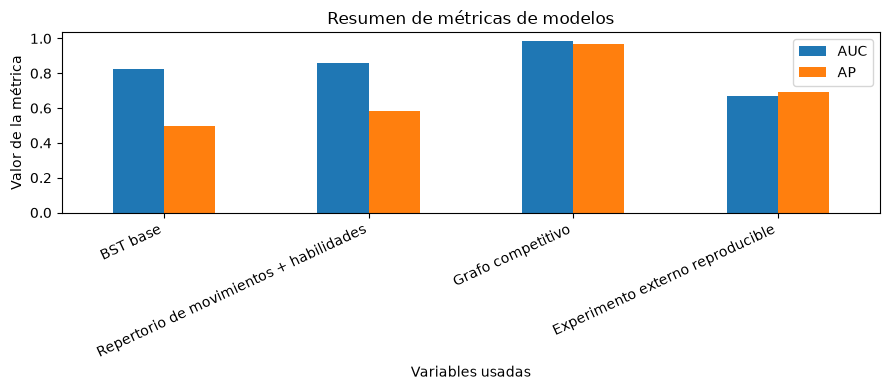

En las métricas de viabilidad OU, el punto de partida con BST base alcanza AUC=0.827 y AP=0.498, mientras que la versión con Grafo competitivo llega a AUC=0.986 y AP=0.970. La mejora sugiere que las relaciones del grafo agregan información útil frente a mirar solo atributos aislados. Al mismo tiempo, un valor tan alto debe leerse con cautela: si las señales competitivas usadas por el modelo están muy cerca de la etiqueta, el desempeño puede reflejar una señal parcialmente circular y no una predicción completamente independiente.

Los experimentos completos de ML se reproducen fuera de este cuaderno con analysis/graph_ml_integrated.py.


In [18]:
metricas_ml = pd.DataFrame([
    {"experimento": "Viabilidad OU", "variables": "BST base", "AUC": 0.827, "AP": 0.498},
    {"experimento": "Viabilidad OU", "variables": "Repertorio de movimientos + habilidades", "AUC": 0.857, "AP": 0.584},
    {"experimento": "Viabilidad OU", "variables": "Grafo competitivo", "AUC": 0.986, "AP": 0.970},
    {"experimento": "Predicción de enlaces COMPATIBLE", "variables": "Experimento externo reproducible", "AUC": 0.670, "AP": 0.694},
])

lecturas_metricas = {
    "BST base": "Modelo base con estadísticas generales; sirve como comparación mínima.",
    "Repertorio de movimientos + habilidades": "Agrega señales funcionales sobre recursos disponibles.",
    "Grafo competitivo": "Agrega estructura relacional; puede contener señal fuerte, pero cercana al objetivo.",
    "Experimento externo reproducible": "Evalúa predicción de enlaces como tarea separada y reproducible."
}

metricas_presentacion = metricas_ml.copy()
metricas_presentacion["lectura"] = metricas_presentacion["variables"].map(lecturas_metricas)
display(metricas_presentacion[["experimento", "variables", "lectura", "AUC", "AP"]])

ax = metricas_ml.set_index('variables')[['AUC', 'AP']].plot.bar(figsize=(9, 4))
ax.set_title('Resumen de métricas de modelos')
ax.set_xlabel('Variables usadas')
ax.set_ylabel('Valor de la métrica')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

base = metricas_ml.iloc[0]
grafo = metricas_ml[metricas_ml['variables'] == 'Grafo competitivo'].iloc[0]
display(Markdown(
    f"En las métricas de viabilidad OU, el punto de partida con {base['variables']} alcanza AUC={base['AUC']:.3f} y AP={base['AP']:.3f}, "
    f"mientras que la versión con {grafo['variables']} llega a AUC={grafo['AUC']:.3f} y AP={grafo['AP']:.3f}. "
    "La mejora sugiere que las relaciones del grafo agregan información útil frente a mirar solo atributos aislados. "
    "Al mismo tiempo, un valor tan alto debe leerse con cautela: si las señales competitivas usadas por el modelo están muy cerca de la etiqueta, "
    "el desempeño puede reflejar una señal parcialmente circular y no una predicción completamente independiente."
))

print("Los experimentos completos de ML se reproducen fuera de este cuaderno con analysis/graph_ml_integrated.py.")


#### 4.6.3 Interpretación y cuidado metodológico

AUC mide qué tan bien el modelo separa casos compatibles de casos no
compatibles. Un valor cercano a 0.5 sería parecido a adivinar al azar, mientras
que un valor más cercano a 1.0 indica una mejor separación. AP resume qué tan
bien el modelo prioriza los casos positivos, lo que resulta útil cuando hay
muchas combinaciones posibles y solo algunas representan vínculos competitivos
relevantes.

Si el modelo con información de grafo mejora al modelo base, eso sugiere que la
estructura relacional contiene señales que no aparecen con la misma claridad en
una tabla plana. En términos estratégicos, el grafo puede ayudar a detectar
pares o relaciones que parecen tener sentido competitivo porque comparten
recursos, se conectan por caminos similares, pertenecen a comunidades cercanas o
se relacionan con patrones observados del metajuego.

Sin embargo, el resultado no debe leerse como prueba de que el grafo predice
perfectamente equipos futuros. Cuando se incorporan relaciones competitivas muy
cercanas a los datos de equipos, el modelo puede estar usando señales demasiado
parecidas a la respuesta que se quiere estimar. Por eso, estas métricas son una
evidencia de que el grafo captura estructura competitiva útil, pero no una
garantía de predicción independiente ni una receta automática para construir
equipos completos.


## 5. Machine Learning integrado

El bloque de ML se conserva como resumen de métricas. La lógica completa vive en
`analysis/graph_ml_integrated.py` y debe ejecutarse por separado cuando se quiera
reproducir el experimento completo.

El resumen compara:

- viabilidad OU con variables base de estadísticas,
- viabilidad OU agregando repertorio de movimientos y habilidades,
- viabilidad OU agregando señales del grafo competitivo,
- predicción de enlaces `COMPATIBLE` como experimento externo reproducible.

No se ejecuta el archivo completo dentro del cuaderno para evitar aumentar el
tiempo de `nbconvert` y para mantener separado el reporte narrativo del
experimento reproducible.


## 6. Conclusiones

El grafo integrado funciona como un motor de razonamiento competitivo porque
conecta recursos, roles y relaciones de equipo. La centralidad muestra qué
Pokémon organizan la red; la similitud por movimientos sugiere sustitutos; el
cuadro de tipos permite razonar sobre perfiles ofensivos y defensivos; las
comunidades de `TEAMMATE_OF` revelan cores; y las rutas heterogéneas explican
por qué una pieza encaja en una estrategia.

El aporte principal frente a una lectura tabular es relacional. Una tabla puede
ordenar por uso, ataque o velocidad; el grafo permite ver cómo una decisión se
conecta con compañeros, cobertura, respuestas defensivas y patrones de co-ocurrencia. Por eso
los resultados deben leerse como apoyo a decisiones estratégicas, no como una
lista automática de mejores Pokémon.

Como alcance temporal, las conclusiones corresponden a Gen 9 OU / Scarlet &
Violet / Smogon. Pokémon Champions puede cambiar el metajuego, por lo que una
extensión natural del proyecto es actualizar la capa competitiva con esos datos
y volver a evaluar centralidades, sustitutos, cores y métricas.


In [19]:
driver.close()
print('Conexión a Neo4j cerrada. Reporte integrado finalizado.')


Conexión a Neo4j cerrada. Reporte integrado finalizado.
